# Explainable AI For  Bankruptcy Prediction
**Model:** XGBoost (The best performing model from our results) 

**Techniques:** SHAP (global + local) · LIME (local) 

**Goal:** Understand *why* the model predicts bankruptcy, not just *that* it does.

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier  
import IPython.core.display as cd
from IPython.display import display, HTML
cd.display = display
cd.HTML = HTML

# Explainability libraries
import shap
from lime import lime_tabular

import warnings
warnings.filterwarnings('ignore')

## 2. Loading Data

In [2]:
poland_df = pd.read_csv('data/poland_df.csv')

X = poland_df.drop(columns=['bankrupt_class', 'bankrupt_after_years'])
y = poland_df['bankrupt_after_years']

# Same split as training notebook
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Same oversampling (fit only on train)
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

print(f'Train shape : {X_train_over.shape}')
print(f'Test shape  : {X_test.shape}')
print(f'Classes     : {sorted(y.unique())}')

Train shape : (198306, 64)
Test shape  : (8681, 64)
Classes     : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## 3. Load the Already Best Model (XGBoost)

In [3]:
with open('models/model_xgb.pkl', 'rb') as f:
    model_xgb = pickle.load(f)
    
print(f'Best params   : {model_xgb.get_params()}')

Best params   : {'memory': None, 'steps': [('xgbclassifier', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...))], 'transform_input': None, 'verbose': False, 'xgbclassifier': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, c

### 3.1 Extract the top 20 features


In [4]:
# Load the DT model to recover the same top 20 features
with open('models/model_dt.pkl', 'rb') as f:
    model_dt = pickle.load(f)

importances = model_dt.named_steps['decisiontreeclassifier'].feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values()
top_20_features = feat_imp.tail(20).index.tolist()

X_train_over = X_train_over[top_20_features]
X_test       = X_test[top_20_features]


### 3.2 Making Predictions with The Test Set

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      8263
           1       0.09      0.16      0.12        82
           2       0.14      0.17      0.15       103
           3       0.09      0.15      0.11        99
           4       0.08      0.09      0.08        80
           5       0.20      0.43      0.27        54

    accuracy                           0.92      8681
   macro avg       0.26      0.32      0.28      8681
weighted avg       0.94      0.92      0.93      8681



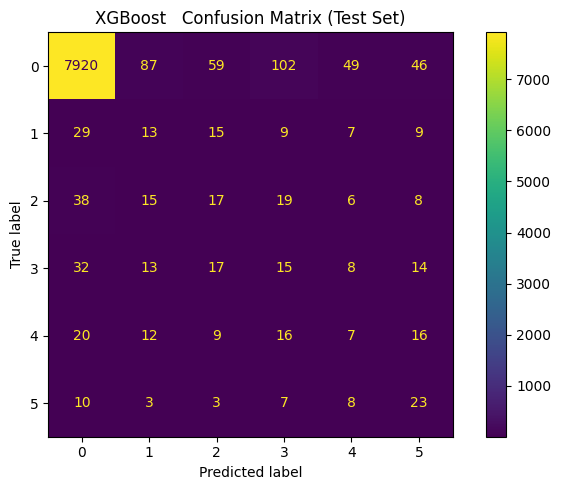

In [5]:
y_pred = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_estimator(model_xgb, X_test, y_test, ax=ax)
ax.set_title('XGBoost   Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

## 4. Preparing Data for Explainers


In [6]:
xgb_model = model_xgb.named_steps['xgbclassifier']

# Compute training medians (used only to satisfy SHAP/LIME's no-NaN requirement)
train_medians = X_train_over.median()

X_train_imp = X_train_over.fillna(train_medians)
X_test_imp  = X_test.fillna(train_medians)

class_names = [str(c) for c in sorted(y.unique())]
print(f'Train shape : {X_train_imp.shape}')
print(f'Test shape  : {X_test_imp.shape}')
print(f'Class names : {class_names}')


Train shape : (198306, 20)
Test shape  : (8681, 20)
Class names : ['0', '1', '2', '3', '4', '5']


## 5. SHAP   Global Explanations
SHAP (Shapley Additive Explanations) answers: **which features drive the model's predictions overall?**

It assigns each feature a fair contribution score based on game theory   features that consistently push predictions higher get positive SHAP values, those that lower predictions get negative values.

In [7]:
# TreeExplainer is optimised specifically for XGBoost   very fast
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_imp)

# shap_values is a list of arrays, one per class
print(f'Number of classes    : {len(shap_values)}')
print(f'SHAP values shape    : {shap_values[0].shape}')


Number of classes    : 8681
SHAP values shape    : (20, 6)


###  SHAP Summary Plot   Global Feature Importance
Shows the **magnitude** of each feature's impact across all test samples. Features at the top matter most.

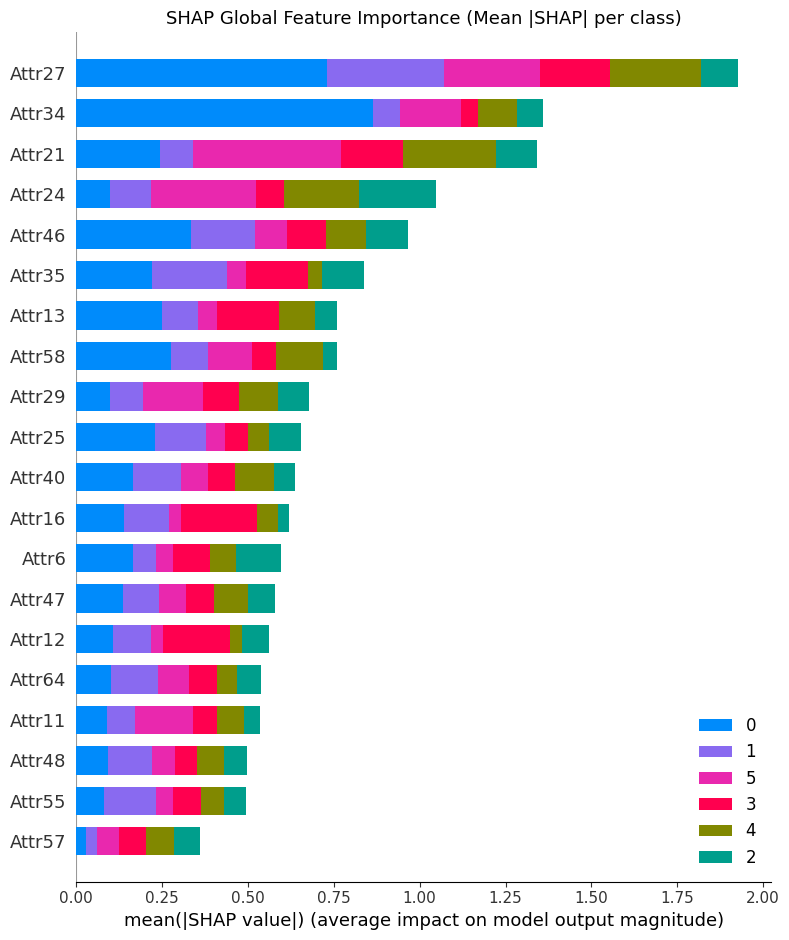

In [8]:
# Mean absolute SHAP across all classes
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,          # full list, one array per class
    X_test_imp,
    plot_type='bar',
    class_names=class_names,
    show=False
)
plt.title('SHAP Global Feature Importance (Mean |SHAP| per class)', fontsize=13)
plt.tight_layout()
plt.show()

### SHAP Heatmap   All Samples at Once
Rows = features, Columns = test samples. Colour intensity = SHAP value magnitude.
Reveals **clusters of similar prediction patterns** in your test set.

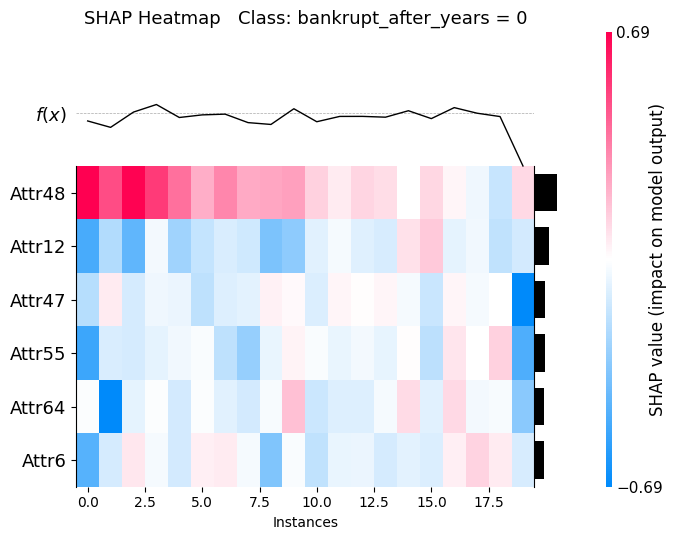

In [9]:
# Use the first class for heatmap (bankrupt soonest)
shap_exp = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value[0],
    data=X_test_imp.values,
    feature_names=top_20_features
)

plt.figure(figsize=(14, 7))
shap.plots.heatmap(shap_exp, show=False, max_display=20)
plt.title(f'SHAP Heatmap   Class: bankrupt_after_years = {class_names[0]}', fontsize=13)
plt.tight_layout()
plt.show()

 
## 6. SHAP   Local Explanations
Local explanations answer: **why did the model make THIS specific prediction for THIS company?**

###  Pick one bankrupt and one non-bankrupt sample

In [10]:
y_test_reset = y_test.reset_index(drop=True)

# Find a sample the model predicted correctly as bankrupt
bankrupt_idx    = y_test_reset[y_test_reset != y_test_reset.max()].index[0]
# Find a sample predicted as the longest surviving (not bankrupt soon)
nonbankrupt_idx = y_test_reset[y_test_reset == y_test_reset.max()].index[0]

print(f'Bankrupt sample index     : {bankrupt_idx}  | True label: {y_test_reset[bankrupt_idx]}')
print(f'Non-bankrupt sample index : {nonbankrupt_idx} | True label: {y_test_reset[nonbankrupt_idx]}')

Bankrupt sample index     : 0  | True label: 0
Non-bankrupt sample index : 242 | True label: 5


###  SHAP Waterfall Plot   Bankrupt Company
Shows how each feature **pushes the prediction** from the base value (average prediction) to the final output.
Red arrows push toward bankruptcy, blue arrows push away.

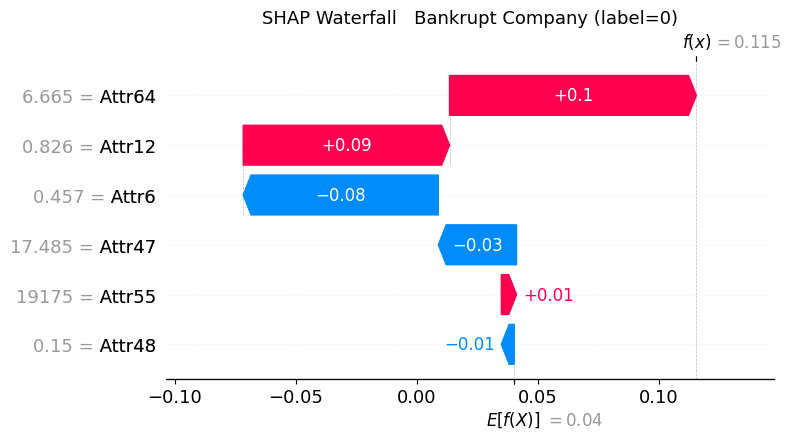

In [11]:
true_class = int(y_test_reset[bankrupt_idx])
class_idx  = class_names.index(str(true_class))

shap_single = shap.Explanation(
    values=shap_values[class_idx][bankrupt_idx],
    base_values=explainer.expected_value[class_idx],
    data=X_test_imp.iloc[bankrupt_idx].values,
    feature_names=top_20_features
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_single, show=False)
plt.title(f'SHAP Waterfall   Bankrupt Company (label={true_class})', fontsize=13)
plt.tight_layout()
plt.show()

## 7. LIME   Local Explanations
LIME (Local Interpretable Model-agnostic Explanations) answers the same local question as SHAP but differently: it **fits a simple linear model** around a single prediction to approximate what the XGBoost model is doing locally.

LIME is model-agnostic and great for cross-checking SHAP results.

In [12]:
# Build the LIME explainer on training data
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_imp.values,
    feature_names=top_20_features,
    class_names=class_names,
    mode='classification',
    random_state=42
)


### 7.1 LIME Local Explanation   Bankrupt Company
Green bars = features that **support** the predicted class. Red bars = features that **contradict** it.
The width of each bar = strength of that feature's local influence.

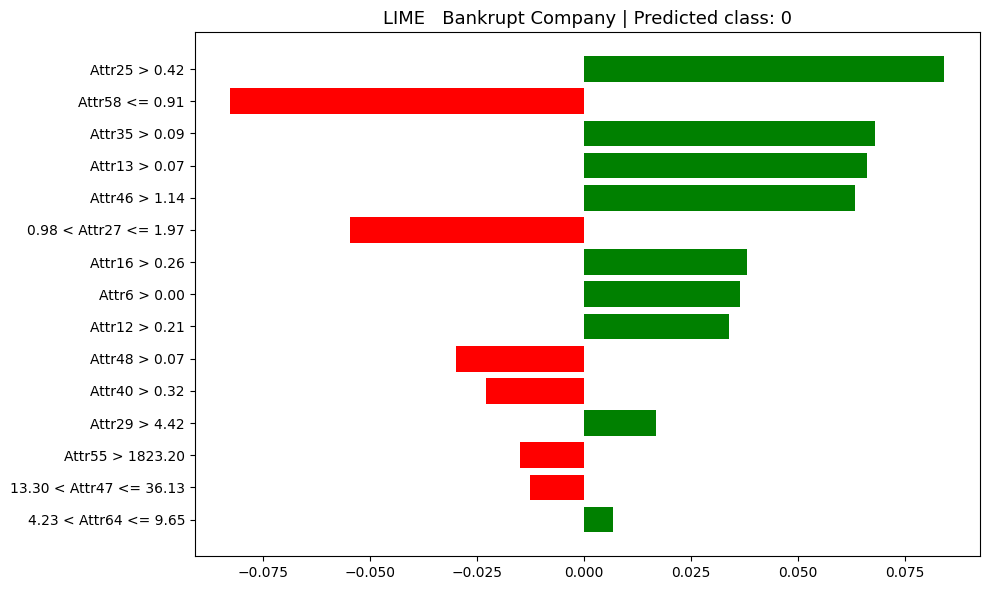

In [13]:
lime_exp_bankrupt = lime_explainer.explain_instance(
    data_row=X_test_imp.iloc[bankrupt_idx].values,
    predict_fn=xgb_model.predict_proba,
    num_features=15,
    top_labels=1
)

fig = lime_exp_bankrupt.as_pyplot_figure(
    label=lime_exp_bankrupt.top_labels[0]
)
fig.set_size_inches(10, 6)
plt.title(
    f'LIME   Bankrupt Company | Predicted class: {lime_exp_bankrupt.top_labels[0]}',
    fontsize=13
)
plt.tight_layout()
plt.show()

### 7.2 LIME Local Explanation   Non-Bankrupt Company

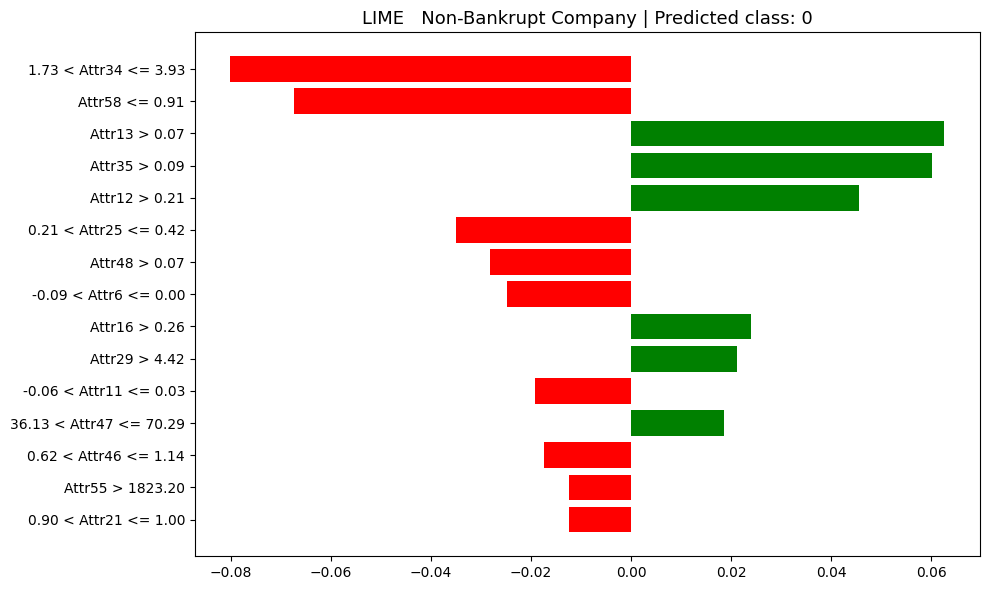

In [14]:
lime_exp_nonbankrupt = lime_explainer.explain_instance(
    data_row=X_test_imp.iloc[nonbankrupt_idx].values,
    predict_fn=xgb_model.predict_proba,
    num_features=15,
    top_labels=1
)

fig = lime_exp_nonbankrupt.as_pyplot_figure(
    label=lime_exp_nonbankrupt.top_labels[0]
)
fig.set_size_inches(10, 6)
plt.title(
    f'LIME   Non-Bankrupt Company | Predicted class: {lime_exp_nonbankrupt.top_labels[0]}',
    fontsize=13
)
plt.tight_layout()
plt.show()

### 7.3 LIME Interactive HTML Report
Full interactive breakdown with probability bars per class   best viewed in Jupyter.

In [15]:
# Bankrupt company   full interactive LIME report
lime_exp_bankrupt.show_in_notebook(show_table=True, show_all=False)

In [16]:
# Non-bankrupt company   full interactive LIME report
lime_exp_nonbankrupt.show_in_notebook(show_table=True, show_all=False)